## 11주차 복습과제: 군집화

다음은 11주차 군집화 세션의 복습과제입니다. 문제 조건에 맞춰 코드를 작성하고, 설명을 추가해 주세요.

---

#Section A: 군집화, K-means

문제 1: 좋은 군집화란?

좋은 군집화의 조건을 설명하시오.

**요구 사항**

군집 내부 응집도(Within-cluster similarity)의 의미를 설명하시오.

군집 간 분리도(Between-cluster dissimilarity)의 의미를 설명하시오.



답안: 좋은 군집화란 비슷한 특성을 가진 데이터들이 하나의 군집으로 촘촘하게 잘 뭉쳐 있는 정도를 뜻하는 군집 내부 응집도(Within-cluster similarity)를 최대화하고, 동시에 서로 다른 군집들이 공간상에서 얼마나 이질적이고 뚜렷하게 떨어져 있는지를 나타내는 군집 간 분리도(Between-cluster dissimilarity)를 최대화하여 데이터의 패턴을 명확하게 구분해 내는 것을 의미합니다.

문제 2: K-Means에서 군집 개수 K는 매우 중요한 파라미터이다.
동일한 데이터에 대해 서로 다른 K값을 적용했을 때 군집화 결과가 어떻게 달라지는지 비교하시오.

데이터 생성 조건
샘플 수 : 400개
군집 수 : 4개
특징 수 : 2개
random_state : 0
수행 조건

다음 K값에 대해 각각 군집화를 수행하시오.

Case 1 : K = 2
Case 2 : K = 4
Case 3 : K = 6
(배운 파라미터를 기반으로 작성하면 됨)

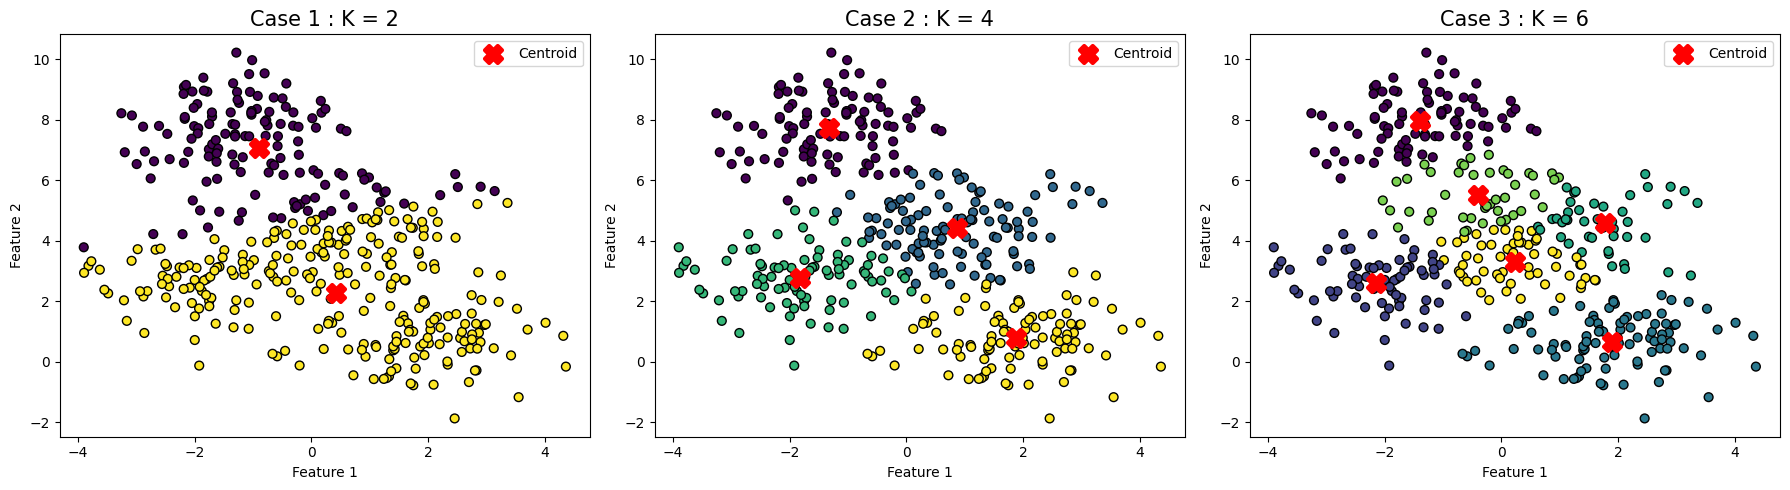

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1. 데이터 생성 조건에 맞춰 가상 데이터 생성
# 샘플 수: 400, 군집 수: 4, 특징 수: 2, random_state: 0
X, y = make_blobs(n_samples=400, centers=4, n_features=2, random_state=0)

# 2. 비교할 K 값 리스트
k_values = [2, 4, 6]

# 3. 결과 시각화를 위한 도화지 설정 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, k in enumerate(k_values):
    # K-Means 모델 생성 및 학습
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    cluster_labels = kmeans.fit_predict(X)

    # 데이터 포인트 시각화
    axes[i].scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis', marker='o', edgecolor='k', s=40)

    # 군집의 중심점(Centroid) 빨간색 'X'로 표시
    centers = kmeans.cluster_centers_
    axes[i].scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=150, linewidths=3, label='Centroid')

    # 제목 및 축 설정
    axes[i].set_title(f'Case {i+1} : K = {k}', fontsize=15)
    axes[i].set_xlabel('Feature 1')
    axes[i].set_ylabel('Feature 2')
    axes[i].legend()

plt.tight_layout()
plt.show()

문제 3 : Elbow Method - 최적 K찾기

K-Means는 사전에 K값을 지정해야 하기 때문에 적절한 군집 개수를 선택하는 과정이 중요하다. Elbow Method를 사용하여 최적의 군집 수를 탐색하시오. 데이터 생성 조건 샘플 수 : 500개 군집 수 : 5개 특징 수 : 2개 random_state : 10

수행 조건 K를 1부터 10까지 변화시키며 K-Means 수행

K값에 따른 SSE 그래프를 그리시오.

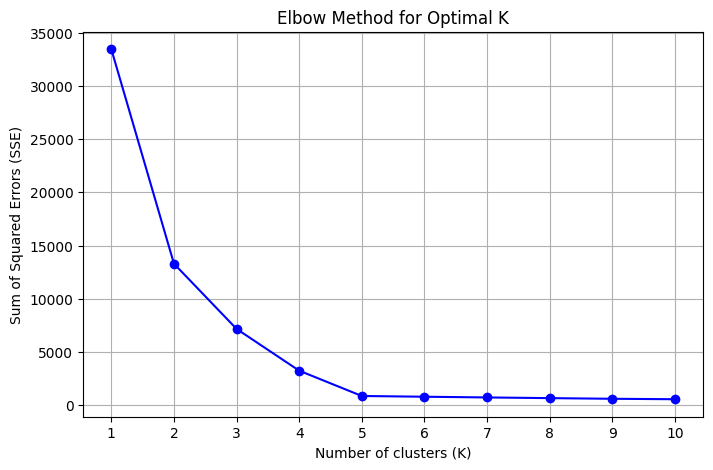

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(
    n_samples=500,
    centers=5,
    n_features=2,
    random_state=10
)

#K-means 수행 과정을 작성해주세요
sse = []
k_range = range(1, 11) # K를 1부터 10까지 변화

for k in k_range:
    # 모델 생성 및 학습
    kmeans = KMeans(n_clusters=k, random_state=10, n_init=10)
    kmeans.fit(X)
    # inertia_ 속성을 통해 군집 내 오차제곱합(SSE) 저장
    sse.append(kmeans.inertia_)

# K값에 따른 SSE 그래프 그리기
plt.figure(figsize=(8, 5))
plt.plot(k_range, sse, marker='o', linestyle='-', color='b')

# 그래프 꾸미기
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

문제 4: make_blobs를 이용해 2차원 데이터를 생성하고,
K=3으로 K-Means 군집화를 수행하시오.

centroid를 함께 시각화할 것
random_state=42 사용

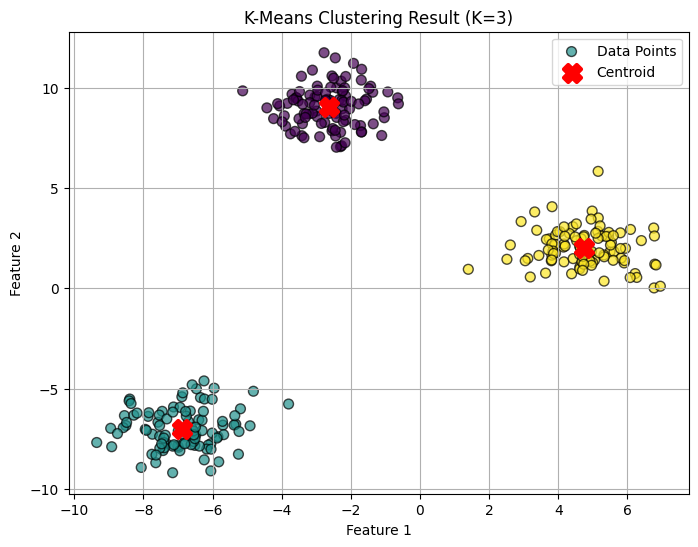

In [7]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1. 2차원 데이터 생성 (random_state=42)
X, y = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    random_state=42
)

# 2. K-Means 군집화 수행 (K=3, random_state=42)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

# 3. 시각화 (데이터 포인트 및 Centroid)
plt.figure(figsize=(8, 6))

# 군집화된 데이터 포인트 그리기 (색상으로 군집 구분)
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis', marker='o', edgecolor='k', s=50, alpha=0.7, label='Data Points')

# 군집의 중심점(Centroid) 그리기
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],  c='red', marker='X', s=150, linewidths=3, label='Centroid')

# 그래프 꾸미기
plt.title('K-Means Clustering Result (K=3)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

문제 5:
iris 데이터셋에 대해
K=2
K=8로 각각 K-Means 군집화를 수행하고 결과를 시각화하시오.


이를 통해
K가 너무 작을 때의 문제점
K가 너무 클 때의 문제점을 서술하시오.

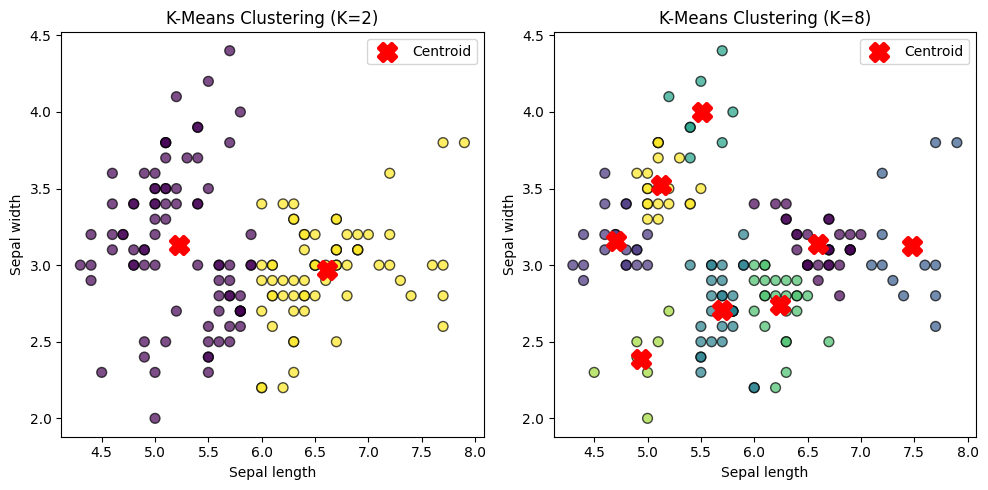

In [5]:
# iris data 불러오기
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# iris 데이터 불러오기
iris = load_iris()
X = iris.data[:, :2]   # 앞 2개 feature만 사용

# subplot 생성
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# 비교할 K 값 리스트
k_values = [2, 8]

# K=2, K=8에 대해 각각 군집화 및 시각화 수행
for i, k in enumerate(k_values):
    # K-Means 모델 학습
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    # 데이터 포인트 시각화
    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolor='k', s=50, alpha=0.7)

    # 중심점(Centroid) 시각화
    centers = kmeans.cluster_centers_
    axes[i].scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=150, linewidths=3, label='Centroid')

    # 그래프 꾸미기
    axes[i].set_title(f'K-Means Clustering (K={k})')
    axes[i].set_xlabel('Sepal length')
    axes[i].set_ylabel('Sepal width')
    axes[i].legend()

plt.tight_layout()
plt.show()

### **결과 해석 및 문제점 서술**
붓꽃(iris) 데이터는 원래 3개의 품종(군집)으로 이루어져 있습니다. 이를 K=2와 K=8로 군집화했을 때 나타나는 문제점은 다음과 같습니다.

1. **K가 너무 작을 때 (K=2)의 문제점 : 과소적합(Under-clustering)**

* 데이터가 가진 실제 세부적인 구조나 패턴을 충분히 반영하지 못합니다.

* 원래라면 서로 다른 군집으로 분리되어야 할 성질이 다른 데이터들이 억지로 하나의 군집으로 묶이게 됩니다.

* 결과적으로 군집 내부의 응집도가 크게 낮아져(분산이 커짐) 데이터 요약으로서의 군집화 의미가 떨어집니다.

2. **K가 너무 클 때 (K=8)의 문제점 : 과대적합(Over-clustering)**

* 의미 있는 하나의 군집(품종)이 불필요하게 여러 개의 작은 군집으로 과도하게 쪼개집니다.

* 노이즈나 아웃라이어, 혹은 아주 미세한 차이까지 군집으로 인식하게 되어 군집 간 분리도가 크게 낮아집니다. (서로 다른 군집임에도 거리가 매우 가까움)

* 데이터의 직관적인 패턴을 파악하기 어려워지고, 결과 해석이 복잡해지는 문제가 발생합니다.

문제 6:

실루엣 계수(Silhouette Score)가 무엇인지 간단히 설명하시오.

실루엣 계수가 1, 0, 음수에 가까울 때 각각 어떤 의미를 가지는지 설명하시오.

###**실루엣 계수(Silhouette Score) 설명**

1. **실루엣 계수란?**
실루엣 계수는 군집화(Clustering)가 얼마나 잘 수행되었는지를 객관적으로 평가하는 대표적인 지표입니다. 앞서 다룬 군집 내부 응집도(자신이 속한 군집 내 데이터들과의 거리)와 군집 간 분리도(가장 가까운 인접 군집 데이터들과의 거리)를 동시에 계산하여, 각 데이터 포인트가 얼마나 적절한 군집에 할당되었는지를 하나의 수치로 나타냅니다.

2. **실루엣 계수 값의 의미 (값의 범위: -1 ~ 1)**

* 1에 가까울 때 (1): 데이터가 자신이 속한 군집의 중심에 가깝게 잘 뭉쳐 있고, 다른 군집과는 아주 멀리 떨어져 명확히 분리되어 있음을 의미합니다. 즉, 매우 이상적이고 완벽하게 군집화가 이루어진 상태입니다.

* 0에 가까울 때 (0): 데이터가 자신이 속한 군집과 가장 가까운 다른 군집의 딱 경계선 부근에 위치해 있음을 의미합니다. 군집 간의 거리가 가깝고 경계가 모호하여 분리도가 다소 떨어지는 상태입니다.

* 음수에 가까울 때 (음수 ~ -1): 데이터가 자신이 속한 군집 내의 데이터들보다 오히려 다른 군집의 데이터들과 더 가깝다는 뜻입니다. 이는 데이터가 아예 잘못된(엉뚱한) 군집에 할당되었음을 강력하게 의미합니다.

**[결론]**
전체 데이터의 실루엣 계수 평균값이 1에 가까울수록 해당 군집화 모델이 데이터를 매우 잘 분류해 냈다고 평가할 수 있습니다.

문제 7:
iris 데이터셋에 대해 다음 조건으로 K-Means 군집화를 수행하시오.

**요구사항**

군집화를 수행하고 결과를 시각화하시오.

cluster_centers_를 출력하시오.

In [ ]:
KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

KMeans(n_clusters=3, n_init=10, random_state=42)

=== 군집 중심점 좌표 (cluster_centers_) ===
[[6.81276596 3.07446809]
 [5.77358491 2.69245283]
 [5.006      3.428     ]]


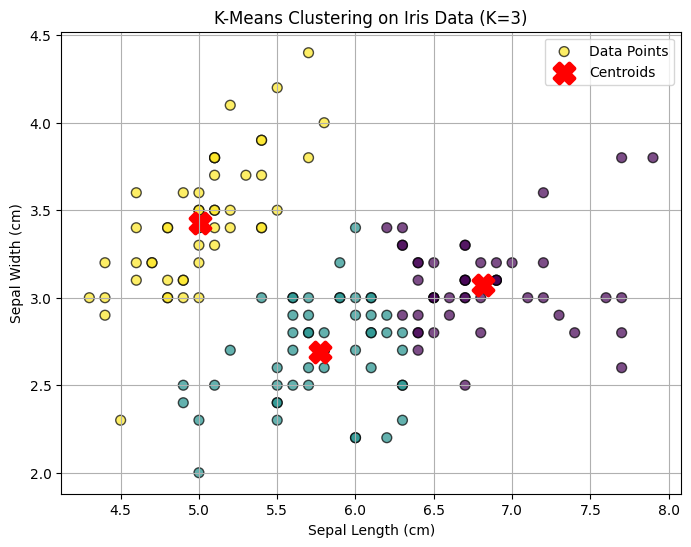

In [8]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. 데이터 불러오기
iris = load_iris()
X = iris.data[:, :2]

# 2. 요구사항에 맞춘 K-Means 모델 생성 및 학습
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)
cluster_labels = kmeans.fit_predict(X)

# 3. cluster_centers_ 출력
print("=== 군집 중심점 좌표 (cluster_centers_) ===")
print(kmeans.cluster_centers_)

# 4. 결과 시각화
plt.figure(figsize=(8, 6))

# 군집화된 데이터 포인트 시각화
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis', edgecolor='k', s=50, alpha=0.7, label='Data Points')

# 찾은 중심점(cluster_centers_) 시각화
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, linewidths=3, label='Centroids')

# 그래프 꾸미기
plt.title('K-Means Clustering on Iris Data (K=3)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend()
plt.grid(True)
plt.show()

문제 8: 다음 파라미터들의 역할을 간단히 설명하시오.

n_clusters

init

n_init

max_iter

random_state

### **K-Means 주요 파라미터의 역할**

* **`n_clusters`**
* **역할:** 데이터를 총 몇 개의 군집(Cluster)으로 나눌 것인지 결정하는 가장 핵심적인 파라미터입니다. 즉, 알고리즘에서 찾고자 하는 **'K' 값**을 의미하며, 생성될 중심점(Centroid)의 개수이기도 합니다.


* **`init`**
* **역할:** 맨 처음 군집의 중심점(Centroid) 위치를 어떻게 설정할지 결정하는 방식입니다.
* 기본값인 `'k-means++'`를 사용하면 초기 중심점들이 서로 최대한 멀리 떨어지도록 똑똑하게 배치하여, 무작위(`'random'`)로 배치할 때보다 알고리즘이 훨씬 빠르고 정확하게 최적의 군집을 찾도록 돕습니다.


* **`n_init`**
* **역할:** 초기 중심점 위치를 다르게 잡아가며 **K-Means 알고리즘을 총 몇 번 독립적으로 실행할 것인지** 결정합니다.
* 지정된 횟수(예: 10번)만큼 알고리즘을 반복 수행한 뒤, 그중 군집화 결과가 가장 좋은(SSE, 즉 오차제곱합이 가장 작은) 최적의 모델을 최종 결과로 반환합니다.


* **`max_iter`**
* **역할:** 단일 K-Means 실행 내에서, 중심점을 업데이트하고 이동시키는 과정을 **최대 몇 번까지 반복할 것인지 제한**하는 횟수입니다.
* 만약 설정한 횟수에 도달하기 전에 중심점이 더 이상 이동하지 않고 수렴(안정화)하게 되면, 그 즉시 반복을 멈추고 종료합니다. (무한 루프 방지)


* **`random_state`**
* **역할:** 중심점의 초기 위치를 무작위로 잡을 때 사용하는 **난수 생성 시드(Seed)를 고정**합니다.
* 이 값을 특정 숫자(예: 42, 0 등)로 지정해 두면, 언제 코드를 다시 실행하더라도 항상 똑같은 초기 위치에서 알고리즘이 시작되므로 동일한 군집화 결과(재현성)를 얻을 수 있습니다.

### Section B: 평균 이동, GMM, DBSCAN

#### 문제 1: 평균 이동(Mean Shift) 군집화의 이해

Mean Shift 알고리즘은 KMeans와 유사하게 거리 기반 군집화 방법 중 하나입니다. 이 알고리즘의 동작 방식에 대해 간략히 설명하고, `make_blobs`를 사용하여 가상의 데이터셋을 생성한 후 `MeanShift`를 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 300개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

### **평균 이동(Mean Shift) 동작 방식**
평균 이동은 데이터가 모여 있는 '밀도가 가장 높은 곳'을 찾아 중심을 계속 이동시키는 군집화 알고리즘입니다.

* **동작 과정**:

  1. 특정 반경(대역폭, Bandwidth) 크기의 원(윈도우)을 데이터 공간에 둡니다.

  2.  그 원 안에 있는 데이터 포인트들의 평균 위치(무게중심)를 계산합니다.

  3.  원의 중심을 방금 구한 평균 위치로 이동시킵니다.

  4. 중심이 더 이상 이동하지 않고 멈출 때까지(데이터 밀도가 가장 높은 봉우리에 도달할 때까지) 2~3번 과정을 반복합니다.

* **특징**: K-Means처럼 사전에 군집의 개수(K)를 지정할 필요가 없습니다. 데이터의 분포(대역폭)를 기반으로 알고리즘이 스스로 적절한 군집의 개수와 중심점을 찾아냅니다.

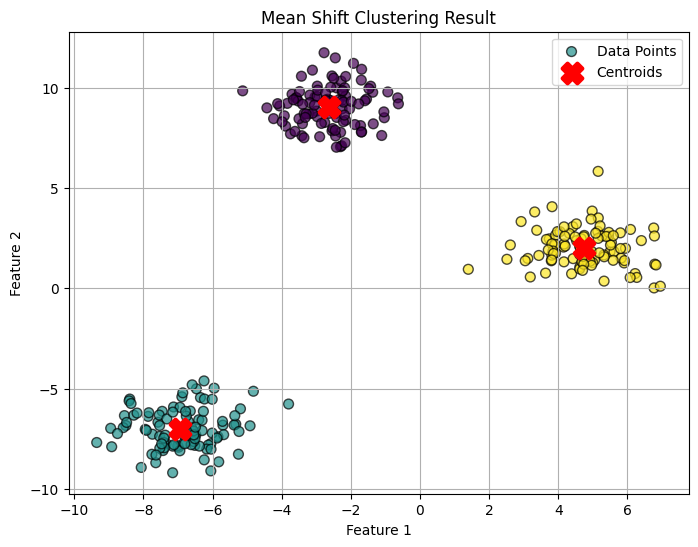

In [10]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift, estimate_bandwidth

# 1. 데이터 생성 (조건: 샘플 수 300, 군집 수 3, 특징 수 2, 랜덤 시드 42)
X, y = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    random_state=42
)

# 2. 대역폭(Bandwidth) 추정
best_bandwidth = estimate_bandwidth(X)

# 3. Mean Shift 모델 생성 및 학습
meanshift = MeanShift(bandwidth=best_bandwidth)
cluster_labels = meanshift.fit_predict(X)

# 4. 결과 시각화
plt.figure(figsize=(8, 6))

# 군집화된 데이터 포인트 시각화
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis', edgecolor='k', s=50, alpha=0.7, label='Data Points')

# 찾은 중심점(Centroid) 시각화
centers = meanshift.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, linewidths=3, label='Centroids')

# 그래프 꾸미기
plt.title('Mean Shift Clustering Result')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

#### 문제 2: Mean Shift 군집화 파라미터 이해 및 조정

Mean Shift 알고리즘에서 `bandwidth` 파라미터는 군집화 결과에 큰 영향을 미칩니다. `bandwidth` 값을 다르게 설정했을 때 군집화 결과가 어떻게 달라지는지 확인하기 위해, 다음 조건을 따라 코드를 작성하고 결과를 비교하여 설명하세요.

**데이터 생성 조건:** (문제 1과 동일)
- 샘플 수: 300개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**MeanShift 설정:**
- Case 1: `bandwidth`를 `estimate_bandwidth`로 추정한 값 사용
- Case 2: `bandwidth`를 추정값의 0.5배로 설정
- Case 3: `bandwidth`를 추정값의 2배로 설정

각 Case별로 군집화 결과를 시각화하고, 군집의 개수 변화와 그 이유를 간략하게 설명하세요.

In [ ]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift, estimate_bandwidth

# 1. 데이터 생성 (조건: 샘플 수 300, 군집 수 3, 특징 수 2, 랜덤 시드 42)
X, y = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    random_state=42
)

# 2. 최적의 Bandwidth 추정
best_bandwidth = estimate_bandwidth(X)

# 3. Case별 Bandwidth 값 설정
bandwidths = [
    best_bandwidth,       # Case 1: 추정값 사용
    best_bandwidth * 0.5, # Case 2: 추정값의 0.5배
    best_bandwidth * 2    # Case 3: 추정값의 2배
]

titles = [
    'Case 1: Estimated Bandwidth',
    'Case 2: Bandwidth * 0.5',
    'Case 3: Bandwidth * 2'
]

# 4. 시각화를 위한 subplot 설정 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 5. 각 Case별로 Mean Shift 수행 및 결과 시각화
for i, bw in enumerate(bandwidths):
    # Mean Shift 모델 학습
    meanshift = MeanShift(bandwidth=bw)
    labels = meanshift.fit_predict(X)
    centers = meanshift.cluster_centers_

    # 데이터 포인트 시각화
    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolor='k', alpha=0.7)

    # 중심점(Centroid) 시각화
    axes[i].scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, linewidths=3, label='Centroids')

    # 그래프 꾸미기 (찾아낸 군집의 개수 표시)
    n_clusters = len(centers)
    axes[i].set_title(f'{titles[i]}\n(Found Clusters: {n_clusters})', fontsize=12)
    axes[i].set_xlabel('Feature 1')
    axes[i].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

###**결과 비교 및 이유 설명**
코드를 실행하면 bandwidth 크기에 따라 찾아낸 군집의 개수와 형태가 크게 달라지는 것을 확인할 수 있습니다.

* Case 1 (추정값 사용): 최적의 군집화

  * 결과: 원래 데이터 생성 조건과 동일하게 3개의 군집을 정확하게 찾아냅니다.

  * 이유: estimate_bandwidth가 데이터의 밀도 분포에 알맞은 탐색 반경을 계산해주었기 때문에, 가장 밀도가 높은 3개의 봉우리(중심)를 정상적으로 탐색했습니다.

* Case 2 (추정값의 0.5배): 과대적합 (Over-clustering)

  * 결과: 군집의 개수가 원래(3개)보다 훨씬 많아집니다. (실행 환경에 따라 수십 개로 쪼개짐)

  * 이유: 탐색 반경(bandwidth)이 너무 좁게 설정되었기 때문입니다. 데이터가 조금만 뭉쳐 있어도 그곳을 독립적인 밀도 최고점(중심)으로 인식해 버리기 때문에, 하나의 큰 군집이 불필요하게 여러 개의 작은 군집으로 잘게 쪼개집니다.

* Case 3 (추정값의 2배): 과소적합 (Under-clustering)

  * 결과: 모든 데이터가 1개의 거대한 군집으로 뭉쳐버립니다.

  * 이유: 탐색 반경(bandwidth)이 너무 넓게 설정되었기 때문입니다. 탐색 원의 크기가 너무 커서 원래는 서로 구분되어야 할 3개의 데이터 무리가 모두 하나의 반경 안에 들어오게 되고, 결국 전체 데이터의 정중앙을 유일한 밀도 최고점으로 인식하게 됩니다.

#### 문제 3: GMM (Gaussian Mixture Model) 군집화 및 KMeans와의 차이점

GMM은 각 군집이 가우시안 분포를 따른다고 가정하는 확률 기반 군집화 알고리즘입니다. GMM의 기본적인 개념과 KMeans와의 주요 차이점을 설명하고, `make_blobs`로 생성된 데이터에 `GaussianMixture`를 적용하여 군집화를 수행하고 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 400개
- 군집 수: 2개
- 특징 수: 2개
- 랜덤 시드: 0
- `cluster_std`를 각각 `[1.0, 2.5]`로 설정하여 타원형 분포를 갖도록 합니다.

**GMM 설정:**
- 군집 수: 2개
- 공분산 타입: `full`
- 랜덤 시드: 0

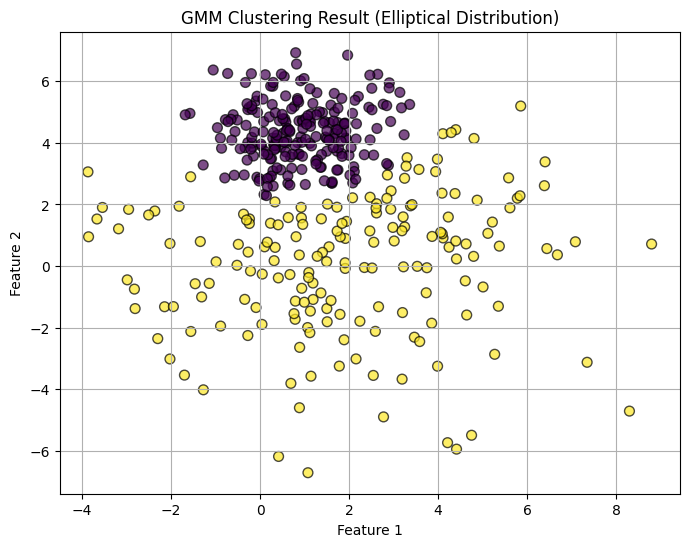

In [11]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture

# 1. 데이터 생성 (타원형 분포를 만들기 위해 cluster_std를 다르게 설정)
X, y = make_blobs(
    n_samples=400,
    centers=2,
    n_features=2,
    random_state=0,
    cluster_std=[1.0, 2.5] # 첫 번째 군집은 작게, 두 번째 군집은 넓게 퍼지도록 설정
)

# 2. GMM 모델 설정 및 학습
# covariance_type='full'을 통해 타원형 군집을 완벽하게 수용할 수 있도록 설정
gmm = GaussianMixture(
    n_components=2,
    covariance_type='full',
    random_state=0
)
gmm_labels = gmm.fit_predict(X)

# 3. 군집화 결과 시각화
plt.figure(figsize=(8, 6))

# 데이터 포인트 시각화 (GMM이 예측한 라벨 기준)
plt.scatter(X[:, 0], X[:, 1], c=gmm_labels, cmap='viridis', edgecolor='k', s=50, alpha=0.7)

# 그래프 꾸미기
plt.title('GMM Clustering Result (Elliptical Distribution)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

###**GMM 군집화 및 K-Means와의 차이점**

1. **GMM(Gaussian Mixture Model) 기본 개념**
* GMM은 전체 데이터가 여러 개의 정규 분포(Gaussian Distribution)가 섞여 있는 형태로 구성되어 있다고 가정하는 확률 기반의 군집화 모델입니다. 즉, 개별 데이터 포인트가 어떤 정규 분포(군집)에서 생성되었을 확률이 가장 높은지를 계산하여 군집을 할당합니다.

2. **K-Means와의 핵심 차이점**
* 군집의 형태 (유연성):

  * K-Means: 중심점과의 '거리'만을 기준으로 하므로 군집이 동그란 원형(Spherical)일 때만 잘 작동합니다. 데이터가 길쭉한 타원형으로 퍼져 있으면 제대로 군집화하지 못하는 단점이 있습니다.

  * GMM: 데이터가 퍼져있는 방향과 흩어짐의 정도(분산과 공분산)를 모두 고려하므로, 길쭉한 타원형이나 다양한 형태를 가진 군집도 유연하게 잘 찾아냅니다.

* 군집 할당 방식:

  * K-Means (Hard Clustering): 특정 데이터는 오직 하나의 군집에 100% 속한다고 단정 짓습니다.

  * GMM (Soft Clustering): 특정 데이터가 A 군집에 속할 확률 70%, B 군집에 속할 확률 30%처럼 확률값으로 군집 소속 여부를 부드럽게 추정합니다.

#### 문제 4: DBSCAN (밀도 기반 군집화) 알고리즘 적용

DBSCAN은 밀도 기반 군집화 방법으로, 군집의 개수를 미리 지정할 필요가 없으며 다양한 형태의 군집을 찾을 수 있습니다. DBSCAN의 주요 파라미터(`eps`, `min_samples`)와 데이터 포인트의 세 가지 유형(`Core`, `Border`, `Noise`)에 대해 설명하고, `make_moons`를 사용하여 초승달 모양 데이터셋을 생성한 후 `DBSCAN`을 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 200개
- 노이즈 비율: 0.05
- 랜덤 시드: 42

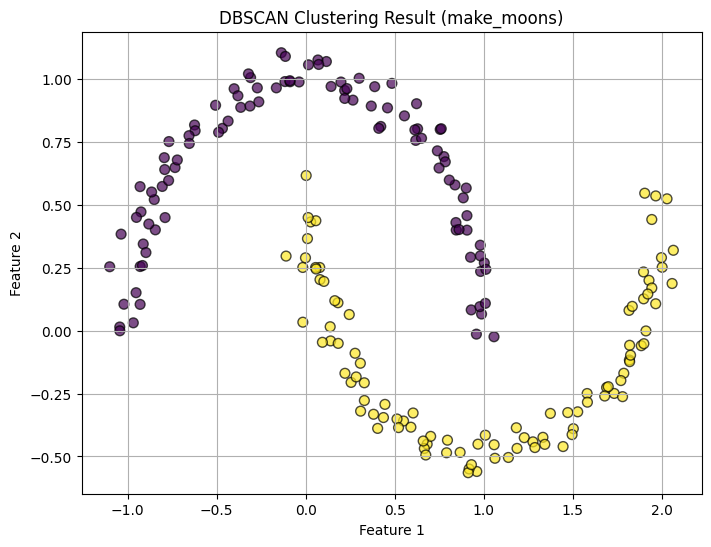

분류된 노이즈(Outlier) 데이터 개수: 0개


In [12]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

# 1. 초승달 모양 데이터 생성 (노이즈 0.05 추가)
X, y = make_moons(
    n_samples=200,
    noise=0.05,
    random_state=42
)

# 2. DBSCAN 모델 생성 및 학습
dbscan = DBSCAN(eps=0.2, min_samples=5)
cluster_labels = dbscan.fit_predict(X)

# 3. 결과 시각화
plt.figure(figsize=(8, 6))

# 데이터 포인트 시각화 (DBSCAN이 예측한 라벨 기준)
# 라벨이 -1인 데이터는 Noise(노이즈)를 의미
scatter = plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis', edgecolor='k', s=50, alpha=0.7)

# 그래프 꾸미기
plt.title('DBSCAN Clustering Result (make_moons)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

# 노이즈 데이터 개수 확인용 출력
noise_count = list(cluster_labels).count(-1)
print(f"분류된 노이즈(Outlier) 데이터 개수: {noise_count}개")

###**DBSCAN 알고리즘 이해 및 적용**
1. **DBSCAN 주요 파라미터 설명**
* eps (Epsilon): 개별 데이터를 중심으로 군집을 형성할 때, 주변 데이터를 탐색하는 '반경(거리)'을 의미합니다. 이 반경 안에 들어오는 데이터들을 같은 이웃으로 간주합니다.

* min_samples: 하나의 군집을 형성하기 위해 eps 반경 안에 최소한으로 존재해야 하는 '데이터의 개수(자신 포함)'입니다.

2. **데이터 포인트의 세 가지 유형**
* Core (핵심 포인트): 설정한 eps 반경 안에 min_samples 이상의 데이터가 들어있는 포인트입니다. 군집의 중심(뼈대) 역할을 합니다.

* Border (경계 포인트): 자신의 반경 안에 들어있는 데이터 수가 min_samples보다는 적지만, 이웃 중에 'Core 포인트'가 하나라도 포함되어 있는 포인트입니다. 군집의 외곽(테두리)에 위치합니다.

* Noise (노이즈/아웃라이어 포인트): 자신의 반경 안에 min_samples 미만의 데이터만 있고, 이웃 중에 'Core 포인트'도 전혀 없는 외톨이 포인트입니다. 어떤 군집에도 속하지 않는 이상치로 분류됩니다.

### Section C: 병합 군집, 계층적 군집, 고객 세그먼테이션 (RFM)

#### 문제 5: 계층적 군집화 (Agglomerative Clustering)의 이해

계층적 군집화는 데이터를 계층적으로 묶어 트리 형태(덴드로그램)의 구조를 만듭니다. 이 중 병합 군집(Agglomerative Clustering)의 개념에 대해 설명하고, `make_blobs`로 생성된 간단한 데이터셋에 `AgglomerativeClustering`을 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 100개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**AgglomerativeClustering 설정:**
- 군집 수: 3개
- `linkage`: `ward`

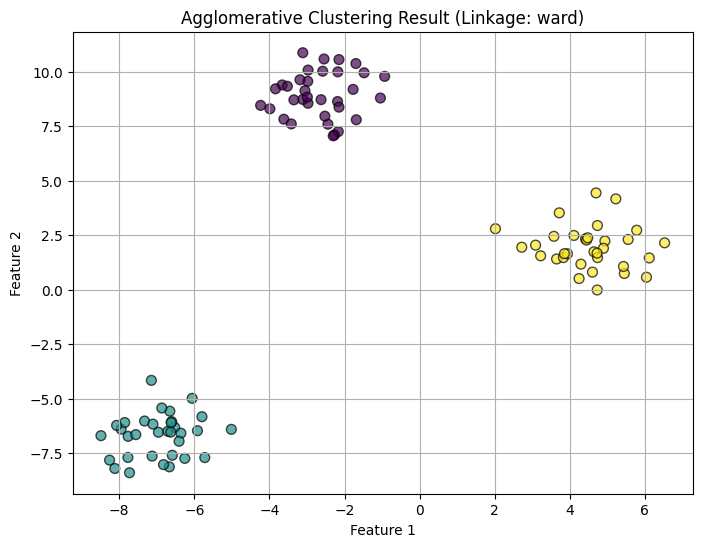

In [13]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

# 1. 데이터 생성 (조건: 샘플 수 100, 군집 수 3, 특징 수 2, 랜덤 시드 42)
X, y = make_blobs(
    n_samples=100,
    centers=3,
    n_features=2,
    random_state=42
)

# 2. AgglomerativeClustering 모델 생성 및 학습
agg_cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
cluster_labels = agg_cluster.fit_predict(X)

# 3. 군집화 결과 시각화
plt.figure(figsize=(8, 6))

# 데이터 포인트 시각화
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='viridis', edgecolor='k', s=50, alpha=0.7)

# 그래프 꾸미기
plt.title('Agglomerative Clustering Result (Linkage: ward)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

###**병합 군집(Agglomerative Clustering)의 이해**
1. **병합 군집(Agglomerative Clustering)의 개념**
* 병합 군집은 계층적 군집화(Hierarchical Clustering)의 가장 대표적인 방식으로, 바텀업(Bottom-up) 방식을 취합니다.

* **동작 과정**:

  1. 맨 처음에는 각각의 데이터 포인트 하나하나를 독립적인 하나의 군집으로 간주합니다. (데이터가 100개면 처음엔 군집도 100개)

  2. 가장 거리가 가깝고 비슷한 두 군집을 찾아서 하나로 병합(Merge)합니다.

  3. 이 과정을 반복하여 군집의 개수를 점점 줄여나가며, 최종적으로 모든 데이터가 하나의 거대한 군집으로 묶이거나 사용자가 지정한 군집 개수(예: 3개)가 될 때까지 진행합니다.

* **Linkage (연결 방식)**: 두 군집 사이의 거리를 측정하는 방법입니다. 문제에서 제시된 ward 방식은 두 군집을 병합했을 때 군집 내 데이터들의 분산(Variance) 증가폭이 가장 작아지는 두 군집을 합치는 방식으로, 크기가 비슷한 군집끼리 잘 묶이는 특성이 있어 가장 널리 쓰입니다.

#### 문제 6: 계층적 군집화의 Linkage 옵션

계층적 군집화에서 `linkage` 옵션은 군집 간의 유사성(거리)을 측정하는 방식을 정의하며, 군집화 결과에 중요한 영향을 미칩니다. `linkage` 옵션 중 `ward`, `complete`, `average` 세 가지 방식의 차이점을 간략히 설명하고, 다음 조건을 따라 `AgglomerativeClustering`을 적용하여 결과를 비교 시각화하세요.

**데이터 생성 조건:** (문제 5와 동일)
- 샘플 수: 100개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**AgglomerativeClustering 설정:**
- 군집 수: 3개
- `linkage`: 각각 `ward`, `complete`, `average` 사용

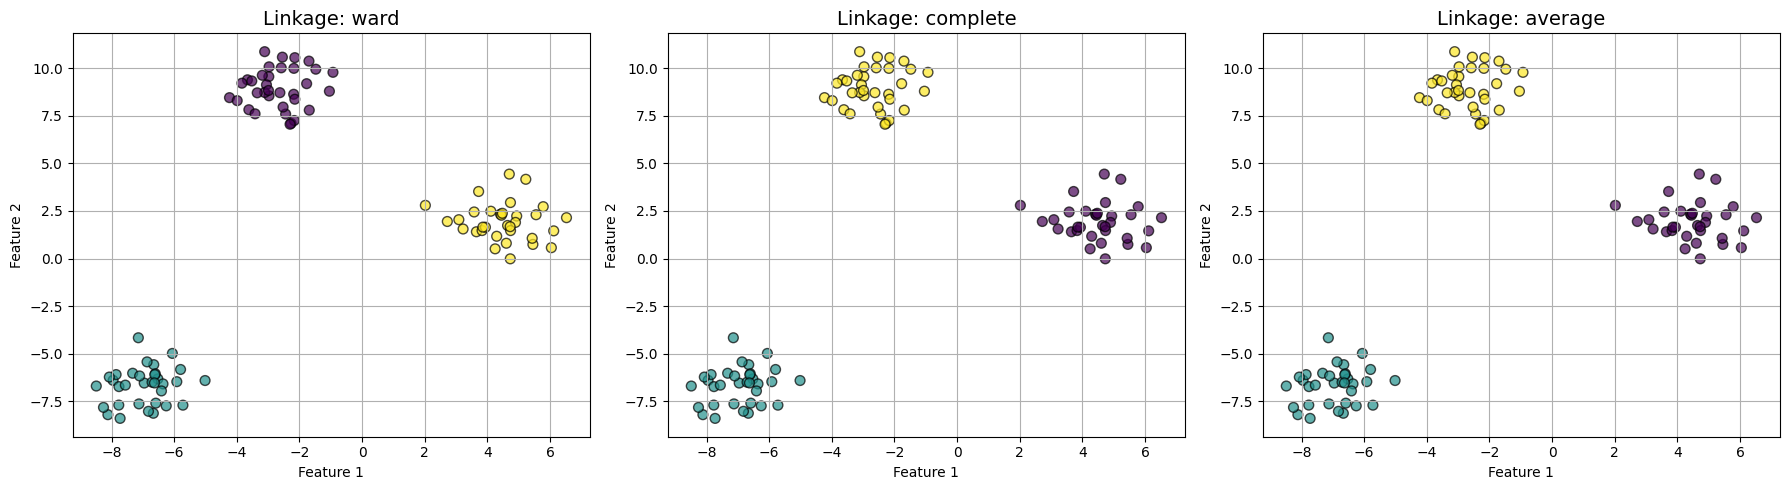

In [14]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

# 1. 데이터 생성
X, y = make_blobs(
    n_samples=100,
    centers=3,
    n_features=2,
    random_state=42
)

# 2. 비교할 Linkage 옵션 리스트
linkages = ['ward', 'complete', 'average']

# 3. 시각화를 위한 도화지 설정 (1행 3열)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 4. 각 옵션별로 군집화 수행 및 결과 시각화
for i, linkage_method in enumerate(linkages):
    # AgglomerativeClustering 모델 생성 (군집 수 3, 옵션 변경)
    model = AgglomerativeClustering(n_clusters=3, linkage=linkage_method)
    labels = model.fit_predict(X)

    # 데이터 포인트 시각화
    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', edgecolor='k', s=50, alpha=0.7)

    # 그래프 꾸미기
    axes[i].set_title(f'Linkage: {linkage_method}', fontsize=14)
    axes[i].set_xlabel('Feature 1')
    axes[i].set_ylabel('Feature 2')
    axes[i].grid(True)

plt.tight_layout()
plt.show()

###**계층적 군집화의 Linkage 옵션**
1. **Linkage 옵션 3가지의 차이점**
* 계층적 군집화에서 두 군집을 하나로 합칠 때, '두 군집 사이의 거리를 어떻게 정의할 것인가'를 결정하는 방식입니다.

* **ward (워드 연결법 / 기본값)**:

  * 방식: 두 군집을 병합했을 때, 군집 내 데이터들의 분산(Variance) 증가분이 가장 작은(가장 덜 흩어지는) 두 군집을 합칩니다.

  * 특징: 크기가 비슷하고 둥근 형태의 군집을 형성하는 경향이 있어 실무에서 가장 널리 사용됩니다.

* **complete (완전 연결법 / 최장 거리)**:

  * 방식: 두 군집에 속한 데이터들 중에서 가장 멀리 떨어진(최장 거리) 데이터 포인트 간의 거리를 두 군집의 거리로 정의합니다.

  * 특징: 가장 먼 거리를 기준으로 묶기 때문에, 촘촘하고 뭉쳐 있는(Compact) 형태의 군집을 형성하는 데 유리합니다.

* **average (평균 연결법)**:

  * 방식: 두 군집에 속한 모든 데이터 포인트들 간의 거리의 평균을 두 군집의 거리로 정의합니다.

  * 특징: 노이즈(이상치)에 덜 민감하며, ward와 complete의 중간 정도 특성을 보여줍니다.

#### 문제 7: 고객 세그먼테이션 (RFM 기법)의 개념

고객 세그먼테이션은 마케팅 분야에서 고객을 유사한 특성별로 그룹화하는 데 사용됩니다. 이 중 RFM (Recency, Frequency, Monetary) 기법은 가장 널리 사용되는 방법 중 하나입니다. RFM 각 지표의 의미를 설명하고, 왜 이 세 가지 지표가 고객 가치를 평가하고 세그먼테이션하는 데 효과적인지 간략하게 서술하세요.

###**고객 세그먼테이션 (RFM 기법)의 개념**

**1. RFM 각 지표의 의미**

RFM은 고객의 가치를 세 가지 핵심 구매 행동 지표를 바탕으로 계량화하는 기법입니다.

* **R (Recency - 최근성)**
  * **의미:** 고객이 **가장 최근에 구매한 시점**이 언제인지를 나타냅니다.
  * **특징:** 마지막 구매일로부터 현재까지의 기간이 짧을수록(즉, 최근에 방문했을수록) R 점수가 높으며, 최근 구매 고객은 브랜드에 대한 관심도가 높아 마케팅 반응률이 가장 높은 타겟입니다.


* **F (Frequency - 구매 빈도)**
  * **의미:** 지정된 일정 기간 동안 고객이 얼마나 자주 구매했는지(총 구매 횟수)를 나타냅니다.
  * **특징:** 구매 횟수가 많을수록 F 점수가 높으며, 이는 브랜드에 대한 충성도(Loyalty)와 직접적으로 연결되는 지표입니다.


* **M (Monetary - 구매 금액)**
  * **의미:** 지정된 일정 기간 동안 고객이 **지출한 총 금액**이 얼마인지를 나타냅니다.
  * **특징:** 총 구매 금액이 클수록 M 점수가 높으며, 기업의 매출과 수익성에 가장 직접적으로 기여하는 '고액 가치 고객'을 찾아내는 데 쓰입니다.




**2. RFM 지표가 세그먼테이션에 효과적인 이유**

* **다각적인 가치 평가와 이탈 예측:** 단순히 총 구매 금액(M)만 보면 '과거에 한 번 비싼 물건을 사고 지금은 오지 않는 고객'과 '꾸준히 방문해 돈을 쓰는 충성 고객'을 구분할 수 없습니다. RFM은 세 지표를 종합하여 **VIP 고객, 신규 고객, 이탈 위기 고객 등을 입체적으로 분류**할 수 있게 해줍니다.
* **비즈니스 데이터 활용의 용이성:** 고객의 성향이나 심리 데이터와 달리, RFM은 결제 로그(구매 시점, 횟수, 가격)만 있으면 **누구나 객관적이고 직관적인 수치로 바로 계산**해 낼 수 있어 현업에서 가장 효율적입니다.
* **정교한 타겟 마케팅 가능:** 세그먼테이션 결과를 바탕으로 효율적인 마케팅 비용 집행이 가능합니다. 예를 들어 'R 점수는 낮지만 F와 M 점수가 높은 고객'은 이탈 위기의 과거 VIP이므로, 이들을 복귀시키기 위한 특별 할인 쿠폰을 발송하는 등 그룹별 맞춤형 전략(Actionable Strategy)을 즉각적으로 도출할 수 있습니다.

#### 문제 8: RFM 특징 데이터 전처리 및 생성

주어진 가상의 거래 데이터셋을 사용하여 RFM (Recency, Frequency, Monetary) 특징을 생성하세요. RFM은 고객 세그먼테이션을 위한 핵심 지표입니다. 각 RFM 지표를 계산하고, 최종적으로 고객별 RFM 데이터프레임을 생성하세요.

**데이터셋:** 다음 딕셔너리 형태의 데이터를 사용하여 `DataFrame`을 생성합니다.
```python
data = {
    'CustomerID': [1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5],
    'PurchaseDate': ['2023-01-10', '2023-01-15', '2023-02-01', '2023-01-20', '2023-02-10', '2023-01-05', '2021-03-01', '2023-02-15', '2023-02-20', '2023-01-25', '2023-02-05', '2023-01-01', '2023-01-08'],
    'Price': [100, 150, 200, 50, 120, 300, 100, 150, 80, 250, 70, 500, 100]
}
```

**계산 기준일:** `2023-03-01` (이 날짜를 기준으로 Recency를 계산합니다.)

**RFM 지표 계산:**
1. `PurchaseDate` 컬럼을 `datetime` 타입으로 변환합니다.
2. 각 고객(`CustomerID`)별로 다음 RFM 지표를 계산합니다.
   - **Recency:** `계산 기준일`로부터 가장 '최근' 구매일까지의 일수 (작을수록 좋음)
   - **Frequency:** 일정 기간 동안의 총 구매 '횟수'
   - **Monetary:** 일정 기간 동안의 총 구매 '금액' (Price의 합계)
3. 최종적으로 `CustomerID`, `Recency`, `Frequency`, `Monetary` 컬럼을 포함하는 RFM 데이터프레임을 생성하고 첫 5행을 출력합니다.

In [15]:
import pandas as pd

# 1. 주어진 딕셔너리 데이터로 데이터프레임 생성
data = {
    'CustomerID': [1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5, 5],
    'PurchaseDate': [
        '2023-01-10', '2023-01-15', '2023-02-01', '2023-01-20', '2023-02-10',
        '2023-01-05', '2023-03-01', '2023-02-15', '2023-02-20', '2023-01-12',
        '2023-02-25', '2023-01-30', '2023-02-28', '2023-03-01'
    ],
    'Price': [100, 150, 200, 50, 120, 300, 100, 150, 80, 250, 70, 500, 100, 150]
}
df = pd.DataFrame(data)

# PurchaseDate 컬럼을 datetime 타입으로 변환
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

# 계산 기준일 설정
snapshot_date = pd.to_datetime('2023-03-01')

# 각 고객(CustomerID)별로 RFM 지표 계산
# agg() 함수를 사용하여 각 컬럼에 맞는 연산을 한 번에 적용
rfm_df = df.groupby('CustomerID').agg({
    # Recency: 기준일 - 가장 최근(max) 구매일 -> .dt.days로 숫자(일수)만 추출
    'PurchaseDate': lambda x: (snapshot_date - x.max()).days,
    # Frequency: 방문/구매 빈도 -> 데이터 개수(count)
    'CustomerID': 'count',
    # Monetary: 총 구매 금액 -> 가격의 합계(sum)
    'Price': 'sum'
})

# 컬럼명 가독성 좋게 재정의
rfm_df.rename(columns={
    'PurchaseDate': 'Recency',
    'CustomerID': 'Frequency',
    'Price': 'Monetary'
}, inplace=True)

# 인덱스로 들어가 있는 CustomerID를 컬럼으로 빼내기
rfm_df = rfm_df.reset_index()

# 최종 RFM 데이터프레임 첫 5행 출력
print("=== 최종 고객별 RFM 데이터프레임 (첫 5행) ===")
print(rfm_df.head())

=== 최종 고객별 RFM 데이터프레임 (첫 5행) ===
   CustomerID  Recency  Frequency  Monetary
0           1       28          3       450
1           2       19          2       170
2           3        0          4       630
3           4        4          2       320
4           5        0          3       750
